# Cluster maps

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyccl as ccl

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Power spectrum

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


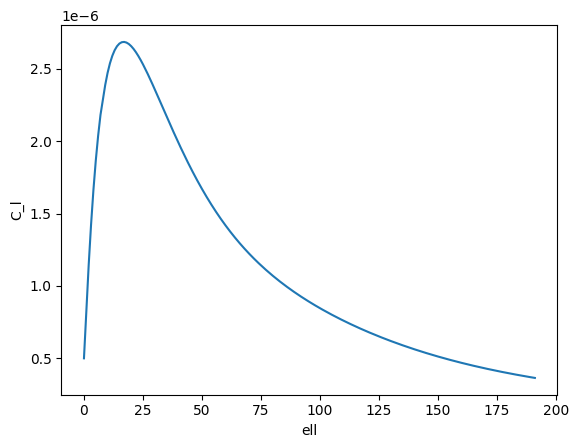

In [3]:
def nz_model(z):
    """Compute the normalized distribution in redshift dependong on the redshift z."""
    return z**2 * np.exp(-(z/0.5)**1.5)


def build_nz(zmin):
    z = np.linspace(0.01, 3.0, 400)
    nz = nz_model(z)
    nz[z < zmin] = 0
    nz /= np.trapz(nz, z)
    return z, nz


def get_Cl_ccl(nside, zmin, Omega_c=0.25, Omega_b=0.05, h=0.67, sigma8=0.8, n_s=0.96, get_ell=False, cosmo=None):
    lmax = 3*nside - 1
    if cosmo is None: cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        sigma8=sigma8,
        n_s=n_s
    )

    ell = np.arange(0, lmax+1)
    z, nz = build_nz(zmin)
    bias = np.ones_like(z)  # b=1
    tracer = ccl.NumberCountsTracer(
        cosmo,
        has_rsd=False,
        dndz=(z, nz),
        bias=(z, bias)
    )

    cl = ccl.angular_cl(cosmo, tracer, tracer, ell, l_limber='auto')
    #print("Cl[ℓ=1] =", cl[0])
    if get_ell: return cl, ell
    else: return cl


cl, ell = get_Cl_ccl(nside, 0, get_ell=True)
plt.plot(ell, cl)
plt.xlabel('ell')
plt.ylabel('C_l');

## Cluster map


Trying to open Dataframe from Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.csv
Concatenating new and former dataframes.

Saving Dataframe results in Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.csv


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1859 (χ²/ndof = 0.0)       │             Nfcn = 1186              │
│ EDM = 6.82e-05 (Goal: 0.0002)    │           time = 14.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │ 0.022e-6  │2550.743e-6│ -0.022e-6  │ 297.138e-6 │    0    │         │       │
│ 1 │ A    │  0.27e-6  │4105.27e-6 │  -0.27e-6  │ 605.56e-6  │    0    │    1    │       │
│ 2 │ l    │   0.007   │  306.737  │   -0.007   │  359.993   │    0    │   360   │       │
│ 3 │ b    │  -89.983  │  152.931  │   -0.017   │  179.983   │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.022e-6 │297.138e-6 │ -0.27e-6  │ 605.56e-6 │  -0.007   │  359.993  │  -0.017   │  179.983  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────┐
│   │        M        A        l        b │
├───┼─────────────────────────────────────┤
│ M │ 2.21e-10        0       -0 -0.38e-9 │
│ A │        0  4.4e-09    -0e-9   203e-9 │
│ l │       -0    -0e-9     9.67       -0 │
│ b │ -0.38e-9   203e-9       -0     11.9 │
└───┴─────────────────────────────────────┘

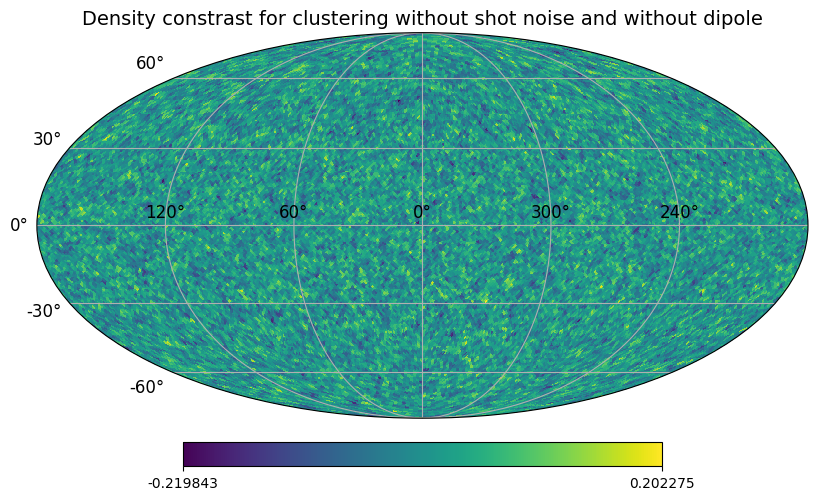

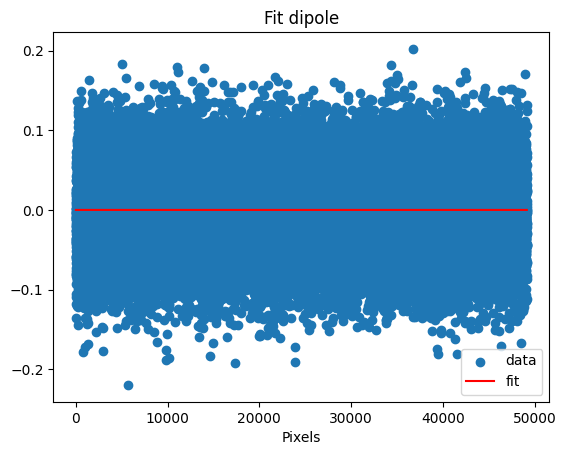

In [4]:
def get_clusterContrast(cl, nside, lognormal=False):
    m = hp.synfast(cl, nside=nside)
    if lognormal: m = np.exp(m - 0.5 * np.var(m)) #Log-Normale transformation
    return m

nest=False
lognormal=False
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="Density constrast for clustering without shot noise and without dipole"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))

output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
get_saveFit_minuit(m, output_path, sufix, np.arange(0, npix), NSource_px_Cl, np.sqrt(np.abs(NSource_px_Cl)))
m

In [5]:
Ntrial = 20
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
x_fit = np.arange(0, npix)
map_cl, fit_cl = [], []
for i in range(Ntrial):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    map = get_clusterContrast(cl, nside, lognormal=False)
    map_cl.append(map)
    m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), verbose=False, plot_fig=False)
    fit_cl.append(m)    
    y_fit_err = np.sqrt(np.abs(map))
    get_saveFit_minuit(m, output_path, sufix, x_fit, map, y_fit_err, verbose=False)
print('Saving complete.')

i = 0	i = 10	Saving complete.


## Reading DataFrame

In [9]:
df = pd.read_csv(output_path + sufix + '.csv')
df

,M,M_init,M_err,M_fixed,M_limits,A,A_init,A_err,A_fixed,A_limits,...,l_limits,b,b_init,b_err,b_fixed,b_limits,valid,x_fit,y_fit,y_fit_err
0,2.620081e-07,1.0,0.001291,False,"(0.0, inf)",6.118236e-05,1.0,0.134196,False,"(0.0, 1.0)",...,"(0.0, 360.0)",30.402825,40.0,150.193438,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.06188112, -0.00319398, -0.0433460...","np.array([0.24875916, 0.05651531, 0.20819711, ..."
1,4.163496e-05,1.0,0.000726,False,"(0.0, inf)",1.031232e-05,1.0,0.004685,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.999988,40.0,153.665372,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.06399485, -0.07127105, 0.0219116...","np.array([0.25297203, 0.26696638, 0.14802582, ..."
2,1.190517e-05,1.0,0.001546,False,"(0.0, inf)",1.771466e-07,1.0,0.003129,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.819438,40.0,151.008334,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.00492158, -0.03103743, -0.0363113...","np.array([0.07015397, 0.17617442, 0.19055528, ..."
3,9.596360e-06,1.0,0.002869,False,"(0.0, inf)",1.075123e-04,1.0,0.000784,False,"(0.0, 1.0)",...,"(0.0, 360.0)",23.689570,40.0,117.253954,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.08542436, 0.04637809, -0.0224089...","np.array([0.29227446, 0.21535572, 0.14969609, ..."
4,3.980303e-06,1.0,0.000013,False,"(0.0, inf)",8.893196e-07,1.0,0.000028,False,"(0.0, 1.0)",...,"(0.0, 360.0)",89.999598,40.0,105.417542,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.01705026, 0.02073984, 0.0987560...","np.array([0.13057665, 0.14401333, 0.31425473, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,1.089667e-07,1000.0,0.001596,False,"(0.0, inf)",8.041027e-07,1.0,0.004092,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-18.439201,40.0,102.855457,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03761789, 0.0054757 , -0.0159318...","np.array([0.19395332, 0.073998 , 0.12622143, ..."
288,6.733206e-06,1000.0,0.004126,False,"(0.0, inf)",2.006727e-06,1.0,0.004518,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.713370,40.0,150.263430,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.05265183, -0.04548844, 0.0118784...","np.array([0.22945987, 0.2132802 , 0.10898818, ..."
289,4.464434e-08,1000.0,0.003022,False,"(0.0, inf)",1.009955e-07,1.0,0.007288,False,"(0.0, 1.0)",...,"(0.0, 360.0)",84.438691,40.0,163.949555,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.03745246, -0.08828277, 0.0178890...","np.array([0.19352637, 0.29712417, 0.1337499 , ..."
290,9.017072e-10,1000.0,0.017510,False,"(0.0, inf)",1.826336e-09,1.0,0.003954,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.999818,40.0,153.644106,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03042208, 0.02496456, -0.0031950...","np.array([0.17441926, 0.15800179, 0.05652466, ..."


In [10]:
mask = (df['valid'] == True) #to select only valid minima in figt.
print("Nb. of non-valid minimum :", len(df[~mask]))
df = df[mask]
print("Nb. of valid minimum :", len(df))
print(f"A mean = {df['A'].mean()} +/- {df['A_err'].mean()}")
print(f"A STD = {df['A'].std()}")

Nb. of non-valid minimum : 15
Nb. of valid minimum : 277
A mean = 3.581767736158092e-05 +/- 0.008539362265136493
A STD = 4.279600960245889e-05


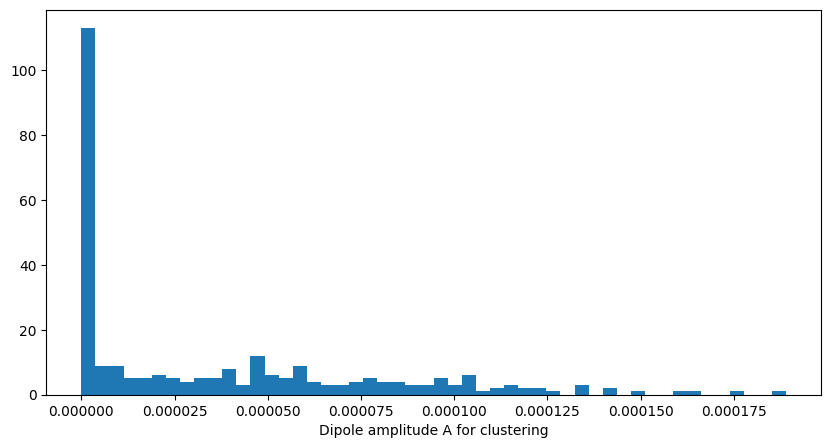

In [11]:
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df['A'], xlabel="Dipole amplitude A for clustering", bins=50, figax=(fig, ax));